# Multiclass results

Here are presented the performance results and the feature importance for 3 models used in multiclass classification tasks;
1. CNN, trained for 40 epochs
2. Transformer, trained for 45 epochs
3. LSTM, trained for 10 epochs

For these experiments, unlike the others, early stopping was not used.

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import os

RESULTS_DIR = os.path.join(os.pardir, "results", "reports", "normal_tests", "normals_removed")
TRANSFORMER_MULTICLASS_DIR = os.path.join(RESULTS_DIR, "transformer")
LSTM_MULTICLASS_DIR = os.path.join(RESULTS_DIR, "lstm")
CNN_MULTICLASS_DIR = os.path.join(RESULTS_DIR, "cnn")

TRANSFORMER_SHAP_VALUES = os.path.join(TRANSFORMER_MULTICLASS_DIR, "with_network_specific_features",
                                        "shap_values_transformer_cybersecurity-unified-multiclass-malicious.csv")
TRANSFORMER_SEP_REMOVED_SHAP_VALUES = os.path.join(TRANSFORMER_MULTICLASS_DIR, "separate_removed_features",
                                        "shap_values_transformer_cybersecurity-unified-multiclass-malicious_removed.csv")
TRANSFORMER_RESULTS = os.path.join(TRANSFORMER_MULTICLASS_DIR, "with_network_specific_features",
                                   "results_transformer_cybersecurity-unified-multiclass-malicious.csv")
TRANSFORMER_SEP_REMOVED_RESULTS = os.path.join(TRANSFORMER_MULTICLASS_DIR, "separate_removed_features",
                                               "results_transformer_cybersecurity-unified-multiclass-malicious_removed.csv")

LSTM_SHAP_VALUES = os.path.join(LSTM_MULTICLASS_DIR, "with_network_specific_features", "shap_values_lstm_cybersecurity-unified-multiclass-malicious.csv")
LSTM_SEP_REMOVED_SHAP_VALUES = os.path.join(LSTM_MULTICLASS_DIR, "separate_removed_features",
                                        "shap_values_lstm_cybersecurity-unified-multiclass-malicious_removed.csv")
LSTM_RESULTS = os.path.join(LSTM_MULTICLASS_DIR, "with_network_specific_features",
                            "results_lstm_cybersecurity-unified-multiclass-malicious.csv")
LSTM_SEP_REMOVED_RESULTS = os.path.join(LSTM_MULTICLASS_DIR, "separate_removed_features",
                                        "results_lstm_cybersecurity-unified-multiclass-malicious_removed.csv")

CNN_SHAP_VALUES = os.path.join(CNN_MULTICLASS_DIR, "with_network_specific_features", 
                               "shap_values_cnn_cybersecurity-unified-multiclass-malicious.csv")
CNN_SEP_REMOVED_SHAP_VALUES = os.path.join(CNN_MULTICLASS_DIR, "separate_removed_features",
                                           "shap_values_cnn_cybersecurity-unified-multiclass-malicious_removed.csv")
CNN_RESULTS = os.path.join(CNN_MULTICLASS_DIR, "with_network_specific_features",
                           "results_cnn_cybersecurity-unified-multiclass-malicious.csv")
CNN_SEP_REMOVED_RESULTS = os.path.join(CNN_MULTICLASS_DIR, "separate_removed_features",
                                       "results_cnn_cybersecurity-unified-multiclass-malicious_removed.csv")


MALWARE_CATEGORIES = ["Botnet", "DoS", "MITM", "Scanner", "Brute force", "Generic", "Exploit", "Infection"]
N_MALWARE_CATEGORIES = len(MALWARE_CATEGORIES)
COLORS = mpl.colormaps["jet"](np.linspace(0,1,N_MALWARE_CATEGORIES))

def plot_shap_values(df: pd.DataFrame, title: str, n_features=6):
    minmaxscaler = MinMaxScaler()
    fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(25,16), dpi=250)
    axs: list[plt.Axes] = axs.flatten()
    for i, category in enumerate(MALWARE_CATEGORIES):
        df = df.sort_values(category, ascending=False)
        features = df["Feature"]
        norm_shap_values = minmaxscaler.fit_transform(df[category].to_numpy().reshape(-1,1)).flatten()
        axs[i].bar(features[:n_features], norm_shap_values[:n_features], color=COLORS[i])
        axs[i].set_title(category)
        axs[i].tick_params(axis="x", labelrotation=15)
    fig.delaxes(axs[-1])
    fig.suptitle(title, fontsize=30)
    fig.subplots_adjust(hspace=0.3)
    fig.savefig("plot.pdf", bbox_inches="tight")

def get_models_performance(transformer_csv: str, cnn_csv: str, lstm_csv: str):
    metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
    metric_dfs = {}
    columns = ["Model"] + MALWARE_CATEGORIES
    transformer_df = pd.read_csv(transformer_csv)
    cnn_df = pd.read_csv(cnn_csv)
    lstm_df = pd.read_csv(lstm_csv)
    for metric in metrics:
        results_df = pd.DataFrame(columns=columns)
        results_df["Model"] = ["Transformer", "CNN", "LSTM"]
        for category in MALWARE_CATEGORIES:
            transformer_metric = transformer_df.loc[transformer_df["Class"] == category][metric].mean()
            cnn_metric = cnn_df.loc[cnn_df["Class"] == category][metric].mean()
            lstm_metric = lstm_df.loc[lstm_df["Class"] == category][metric].mean()
            results_df[category] = [transformer_metric, cnn_metric, lstm_metric]
        results_df = results_df.set_index("Model")
        metric_dfs[metric] = results_df
    results_df = pd.concat(metric_dfs, names=["Metric", "Model"])
    return results_df


## Performance summary
### All network specific features included

In [2]:
df_all_features = get_models_performance(TRANSFORMER_RESULTS, CNN_RESULTS, LSTM_RESULTS)
df_all_features

Botnet       DoS      MITM   Scanner  Brute force  \
Metric    Model                                                              
Accuracy  Transformer  0.707963  0.368618  0.960542  0.872845     0.380557   
          CNN          0.408201  0.159769  0.883297  0.541534     0.280884   
          LSTM         0.785862  0.276990  0.998640  0.447910     0.989635   
Precision Transformer  0.542450  0.702488  0.694973  0.915634     0.937784   
          CNN          0.372777  0.273602  0.549417  0.550446     0.768606   
          LSTM         0.481712  0.809681  0.976862  0.928405     0.976212   
Recall    Transformer  0.707963  0.368618  0.960542  0.872845     0.380557   
          CNN          0.408201  0.159769  0.883297  0.541534     0.280884   
          LSTM         0.785862  0.276990  0.998640  0.447910     0.989635   
F1 Score  Transformer  0.570613  0.404941  0.806433  0.893613     0.541262   
          CNN          0.354386  0.164815  0.643862  0.491614     0.395826   
          LSTM         0.491119  0.306130  0.987622  0.585719     0.982846   

                        Generic   Exploit  Infection  
Metric    Model                                       
Accuracy  Transformer  0.984696  0.895449   0.575511  
          CNN          0.984112  0.702528   0.314723  
          LSTM         0.990732  0.974809   0.945405  
Precision Transformer  0.573214  0.931861   0.956906  
          CNN          0.561673  0.745577   0.638507  
          LSTM         0.996796  0.930341   0.970104  
Recall    Transformer  0.984696  0.895449   0.575511  
          CNN          0.984112  0.702528   0.314723  
          LSTM         0.990732  0.974809   0.945405  
F1 Score  Transformer  0.724606  0.913280   0.718602  
          CNN          0.714963  0.710842   0.398049  
          LSTM         0.993751  0.951717   0.957152

### Separate removed features

In [3]:
df_removed_features = get_models_performance(TRANSFORMER_SEP_REMOVED_RESULTS, CNN_SEP_REMOVED_RESULTS, LSTM_SEP_REMOVED_RESULTS)

with pd.ExcelWriter("multiclass_results.xlsx", engine="xlsxwriter") as writer:
    df_all_features.to_excel(writer, sheet_name="All features included")
    df_removed_features.to_excel(writer, sheet_name="Separate removed features")

df_removed_features

Botnet       DoS      MITM   Scanner  Brute force  \
Metric    Model                                                              
Accuracy  Transformer  0.974819  0.961687  0.997793  0.985591     0.984028   
          CNN          0.453972  0.427783  0.904381  0.865277     0.791604   
          LSTM         0.604197  0.365273  0.996624  0.480723     0.966759   
Precision Transformer  0.994484  0.991147  0.975013  0.997807     0.972740   
          CNN          0.474150  0.634065  0.771886  0.658780     0.756808   
          LSTM         0.508623  0.699141  0.977454  0.875226     0.941071   
Recall    Transformer  0.974819  0.961687  0.997793  0.985591     0.984028   
          CNN          0.453972  0.427783  0.904381  0.865277     0.791604   
          LSTM         0.604197  0.365273  0.996624  0.480723     0.966759   
F1 Score  Transformer  0.984548  0.976182  0.986267  0.991658     0.978338   
          CNN          0.452476  0.456408  0.829817  0.711752     0.769920   
          LSTM         0.393311  0.335639  0.986938  0.570909     0.953126   

                        Generic   Exploit  Infection  
Metric    Model                                       
Accuracy  Transformer  0.993082  0.969321   0.954768  
          CNN          0.961150  0.616462   0.751189  
          LSTM         0.987535  0.951297   0.911127  
Precision Transformer  0.994746  0.942633   0.954829  
          CNN          0.983484  0.557167   0.807345  
          LSTM         0.989097  0.900026   0.959546  
Recall    Transformer  0.993082  0.969321   0.954768  
          CNN          0.961150  0.616462   0.751189  
          LSTM         0.987535  0.951297   0.911127  
F1 Score  Transformer  0.993911  0.955761   0.954783  
          CNN          0.972046  0.580693   0.774453  
          LSTM         0.988200  0.924566   0.931508

## Feature importance
### Transformer
#### All network specific features included

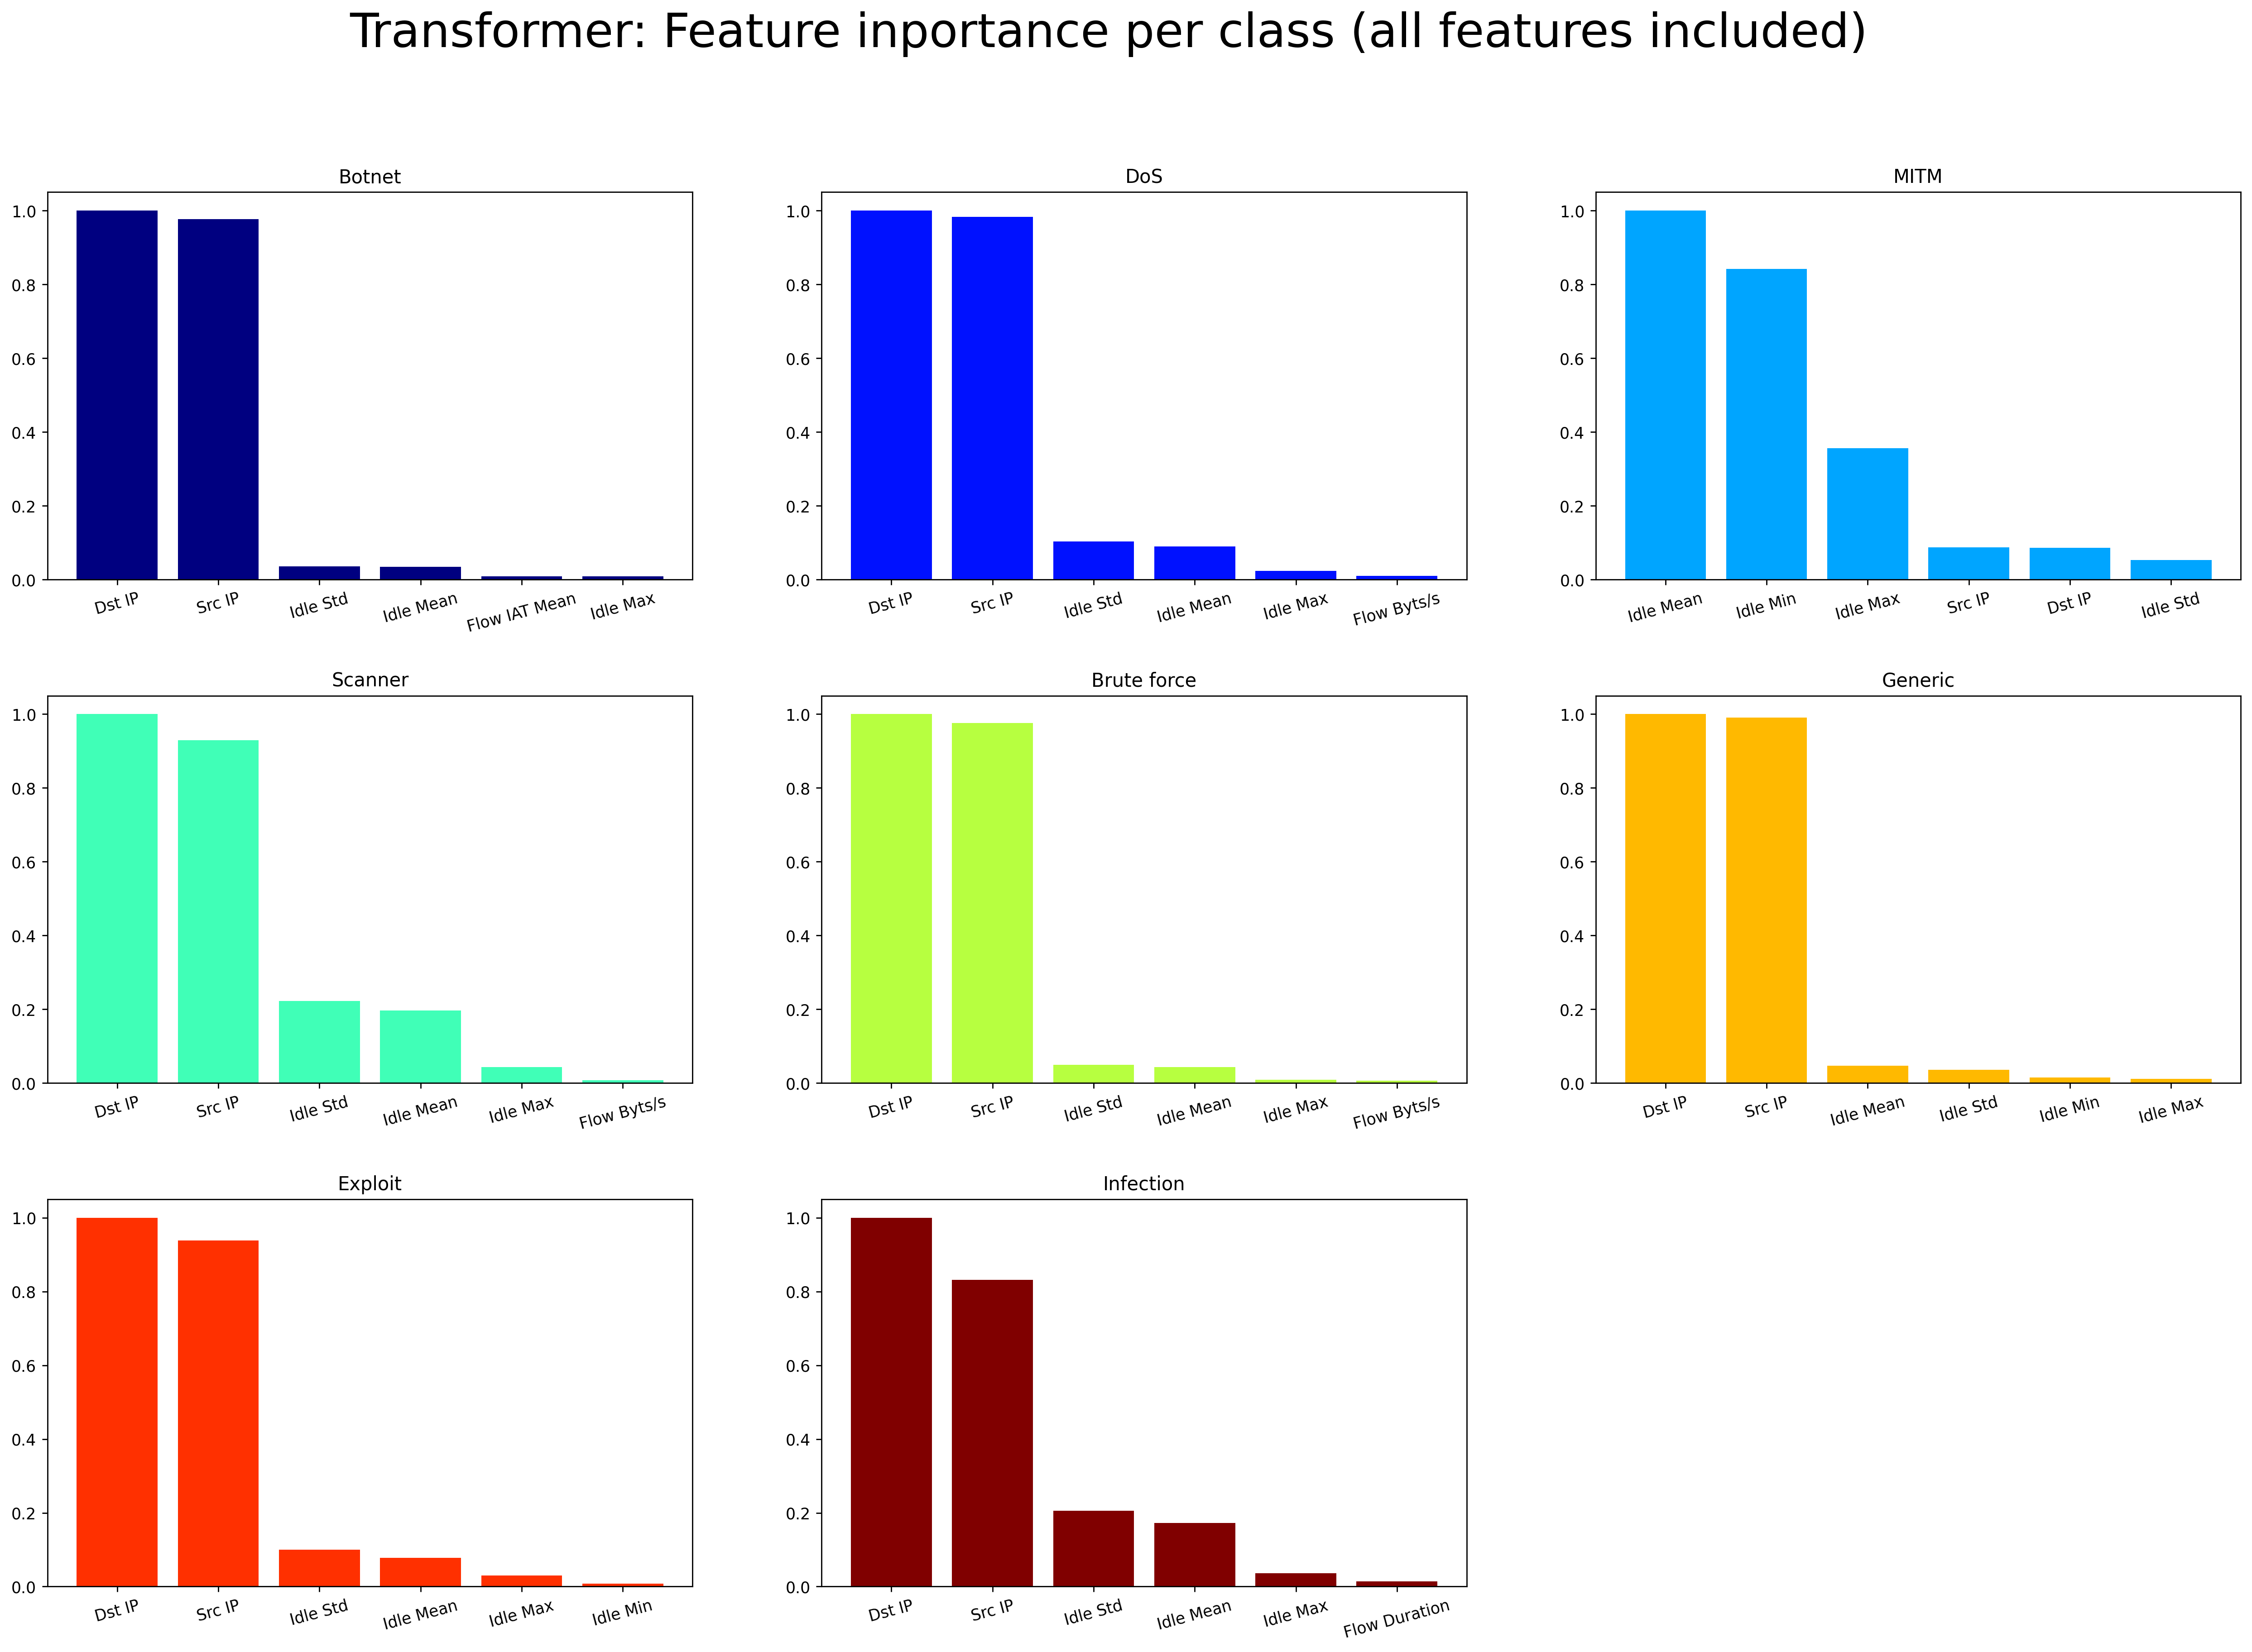

In [4]:
plot_shap_values(pd.read_csv(TRANSFORMER_SHAP_VALUES), "Transformer: Feature inportance per class (all features included)")

#### Separate removed features

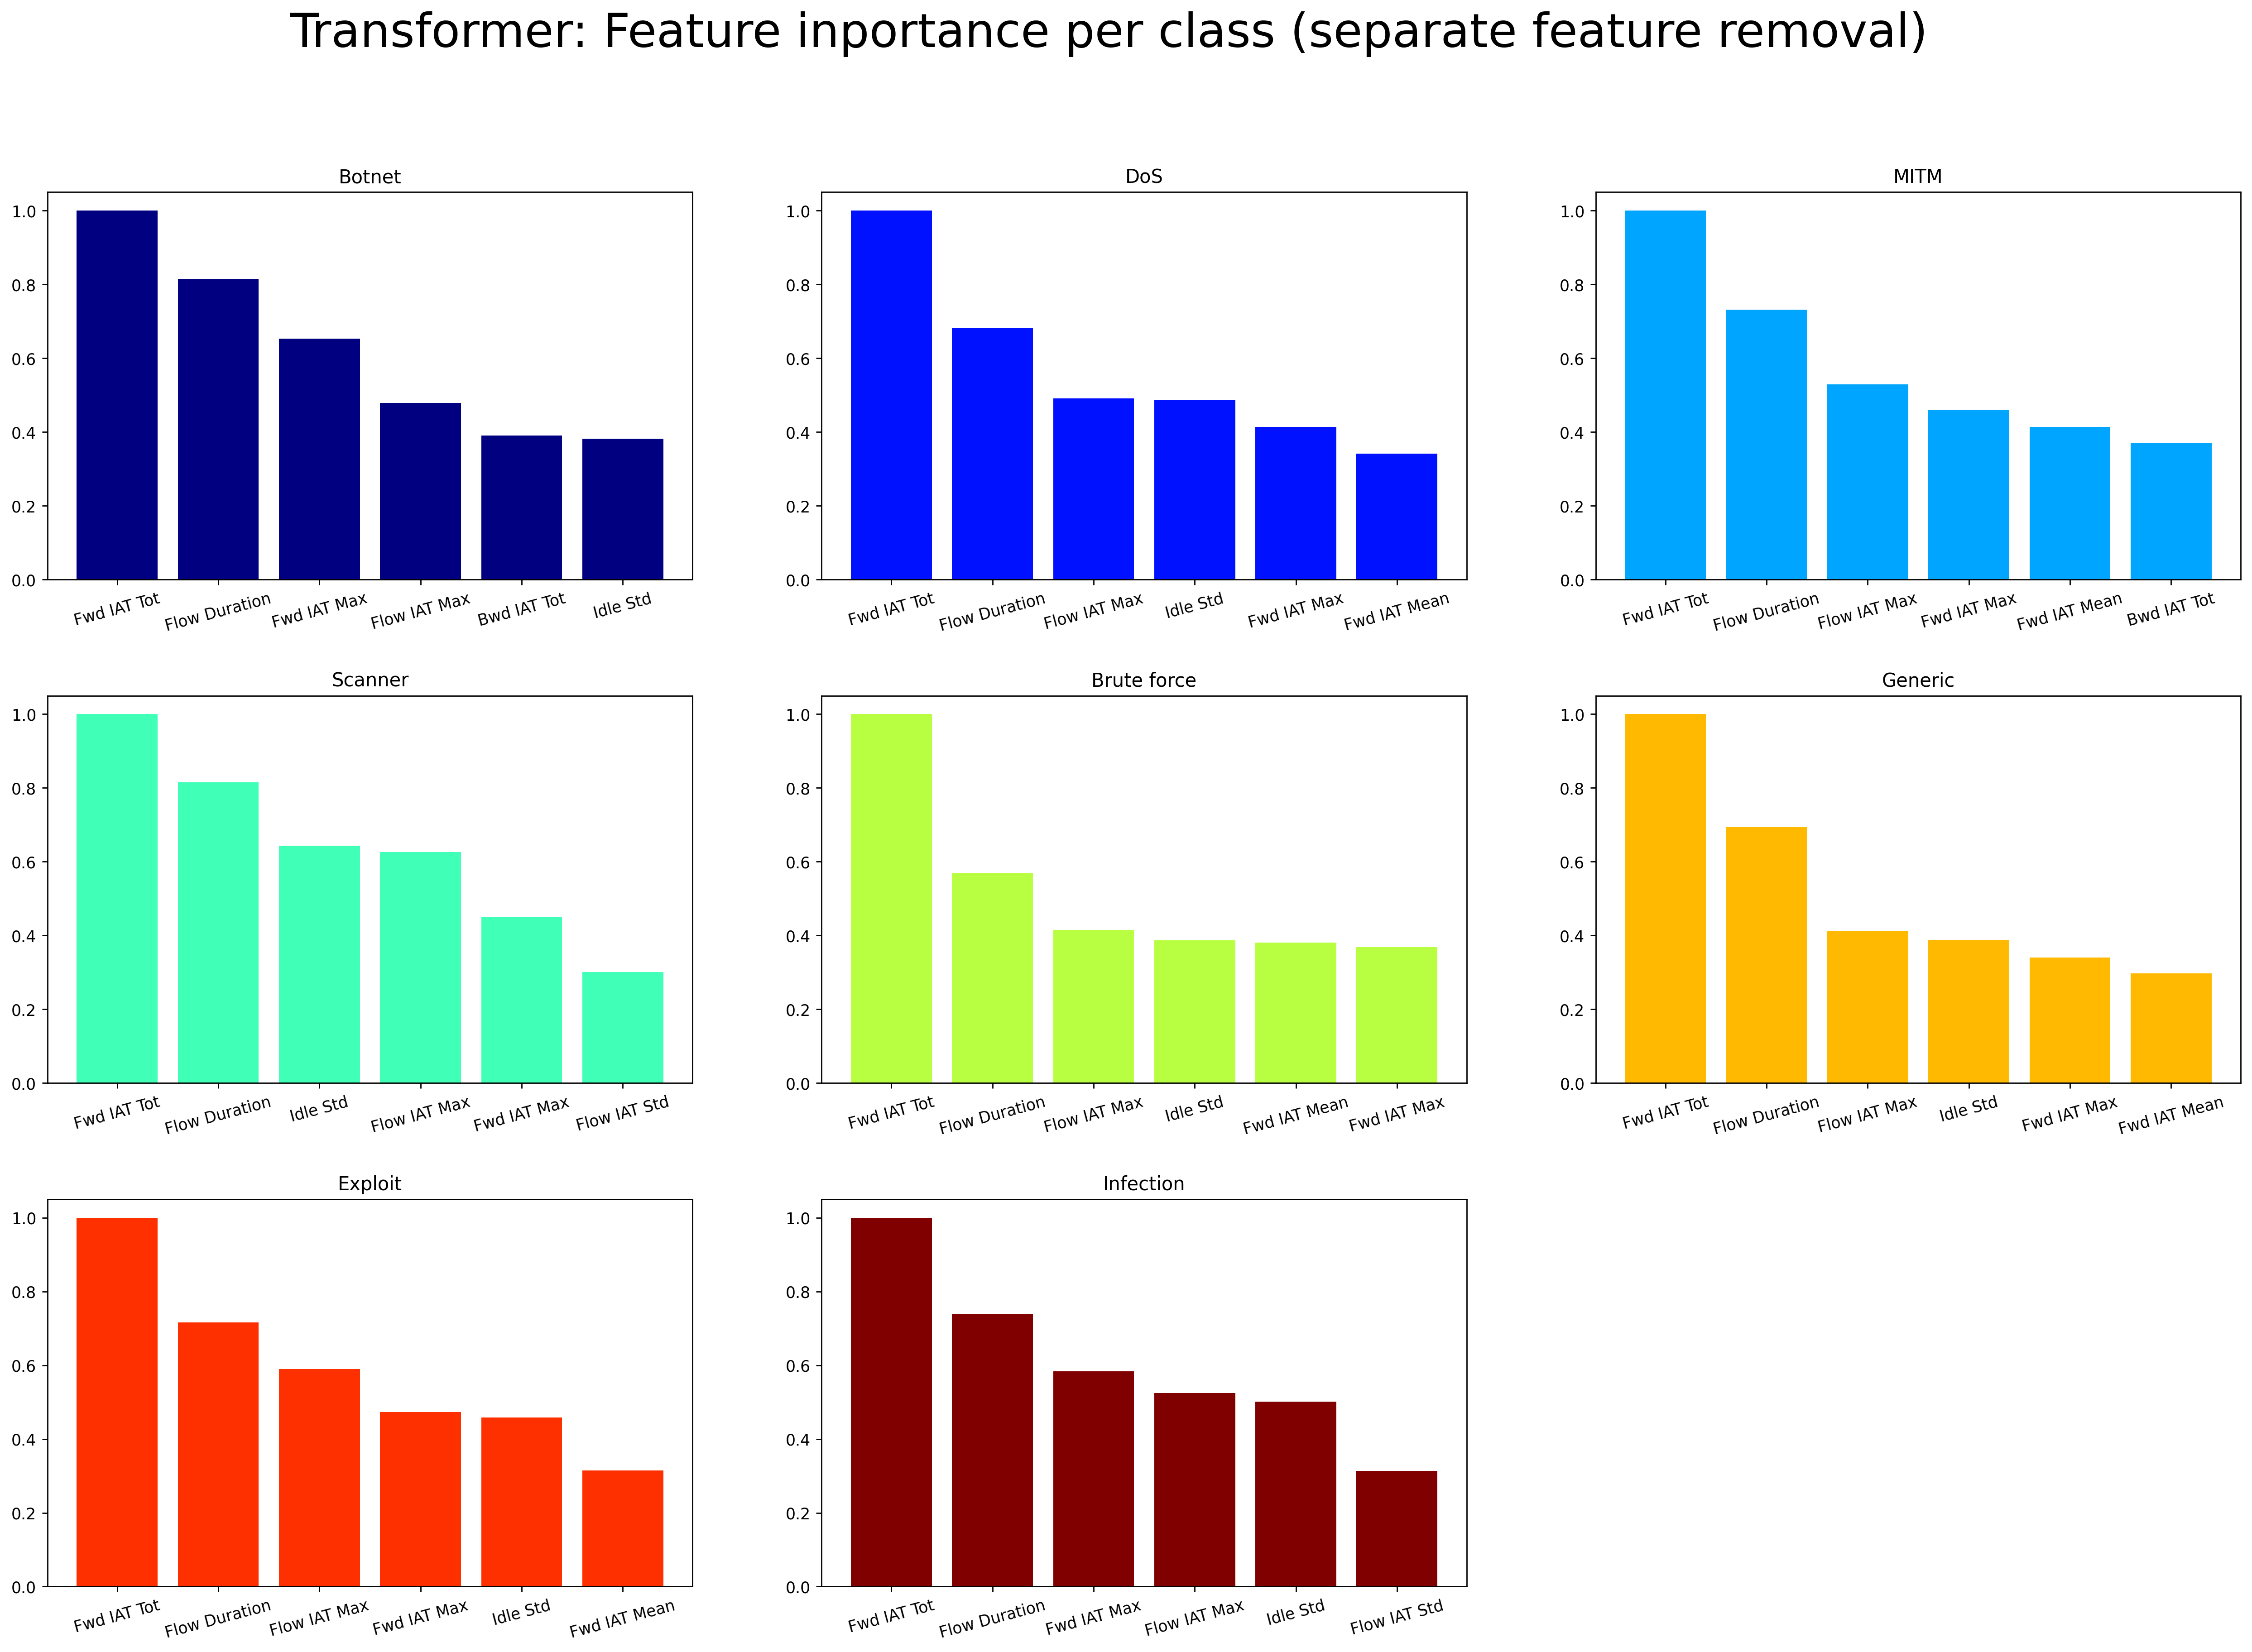

In [5]:
plot_shap_values(pd.read_csv(TRANSFORMER_SEP_REMOVED_SHAP_VALUES), "Transformer: Feature inportance per class (separate feature removal)")

### LSTM
#### All network specific features included

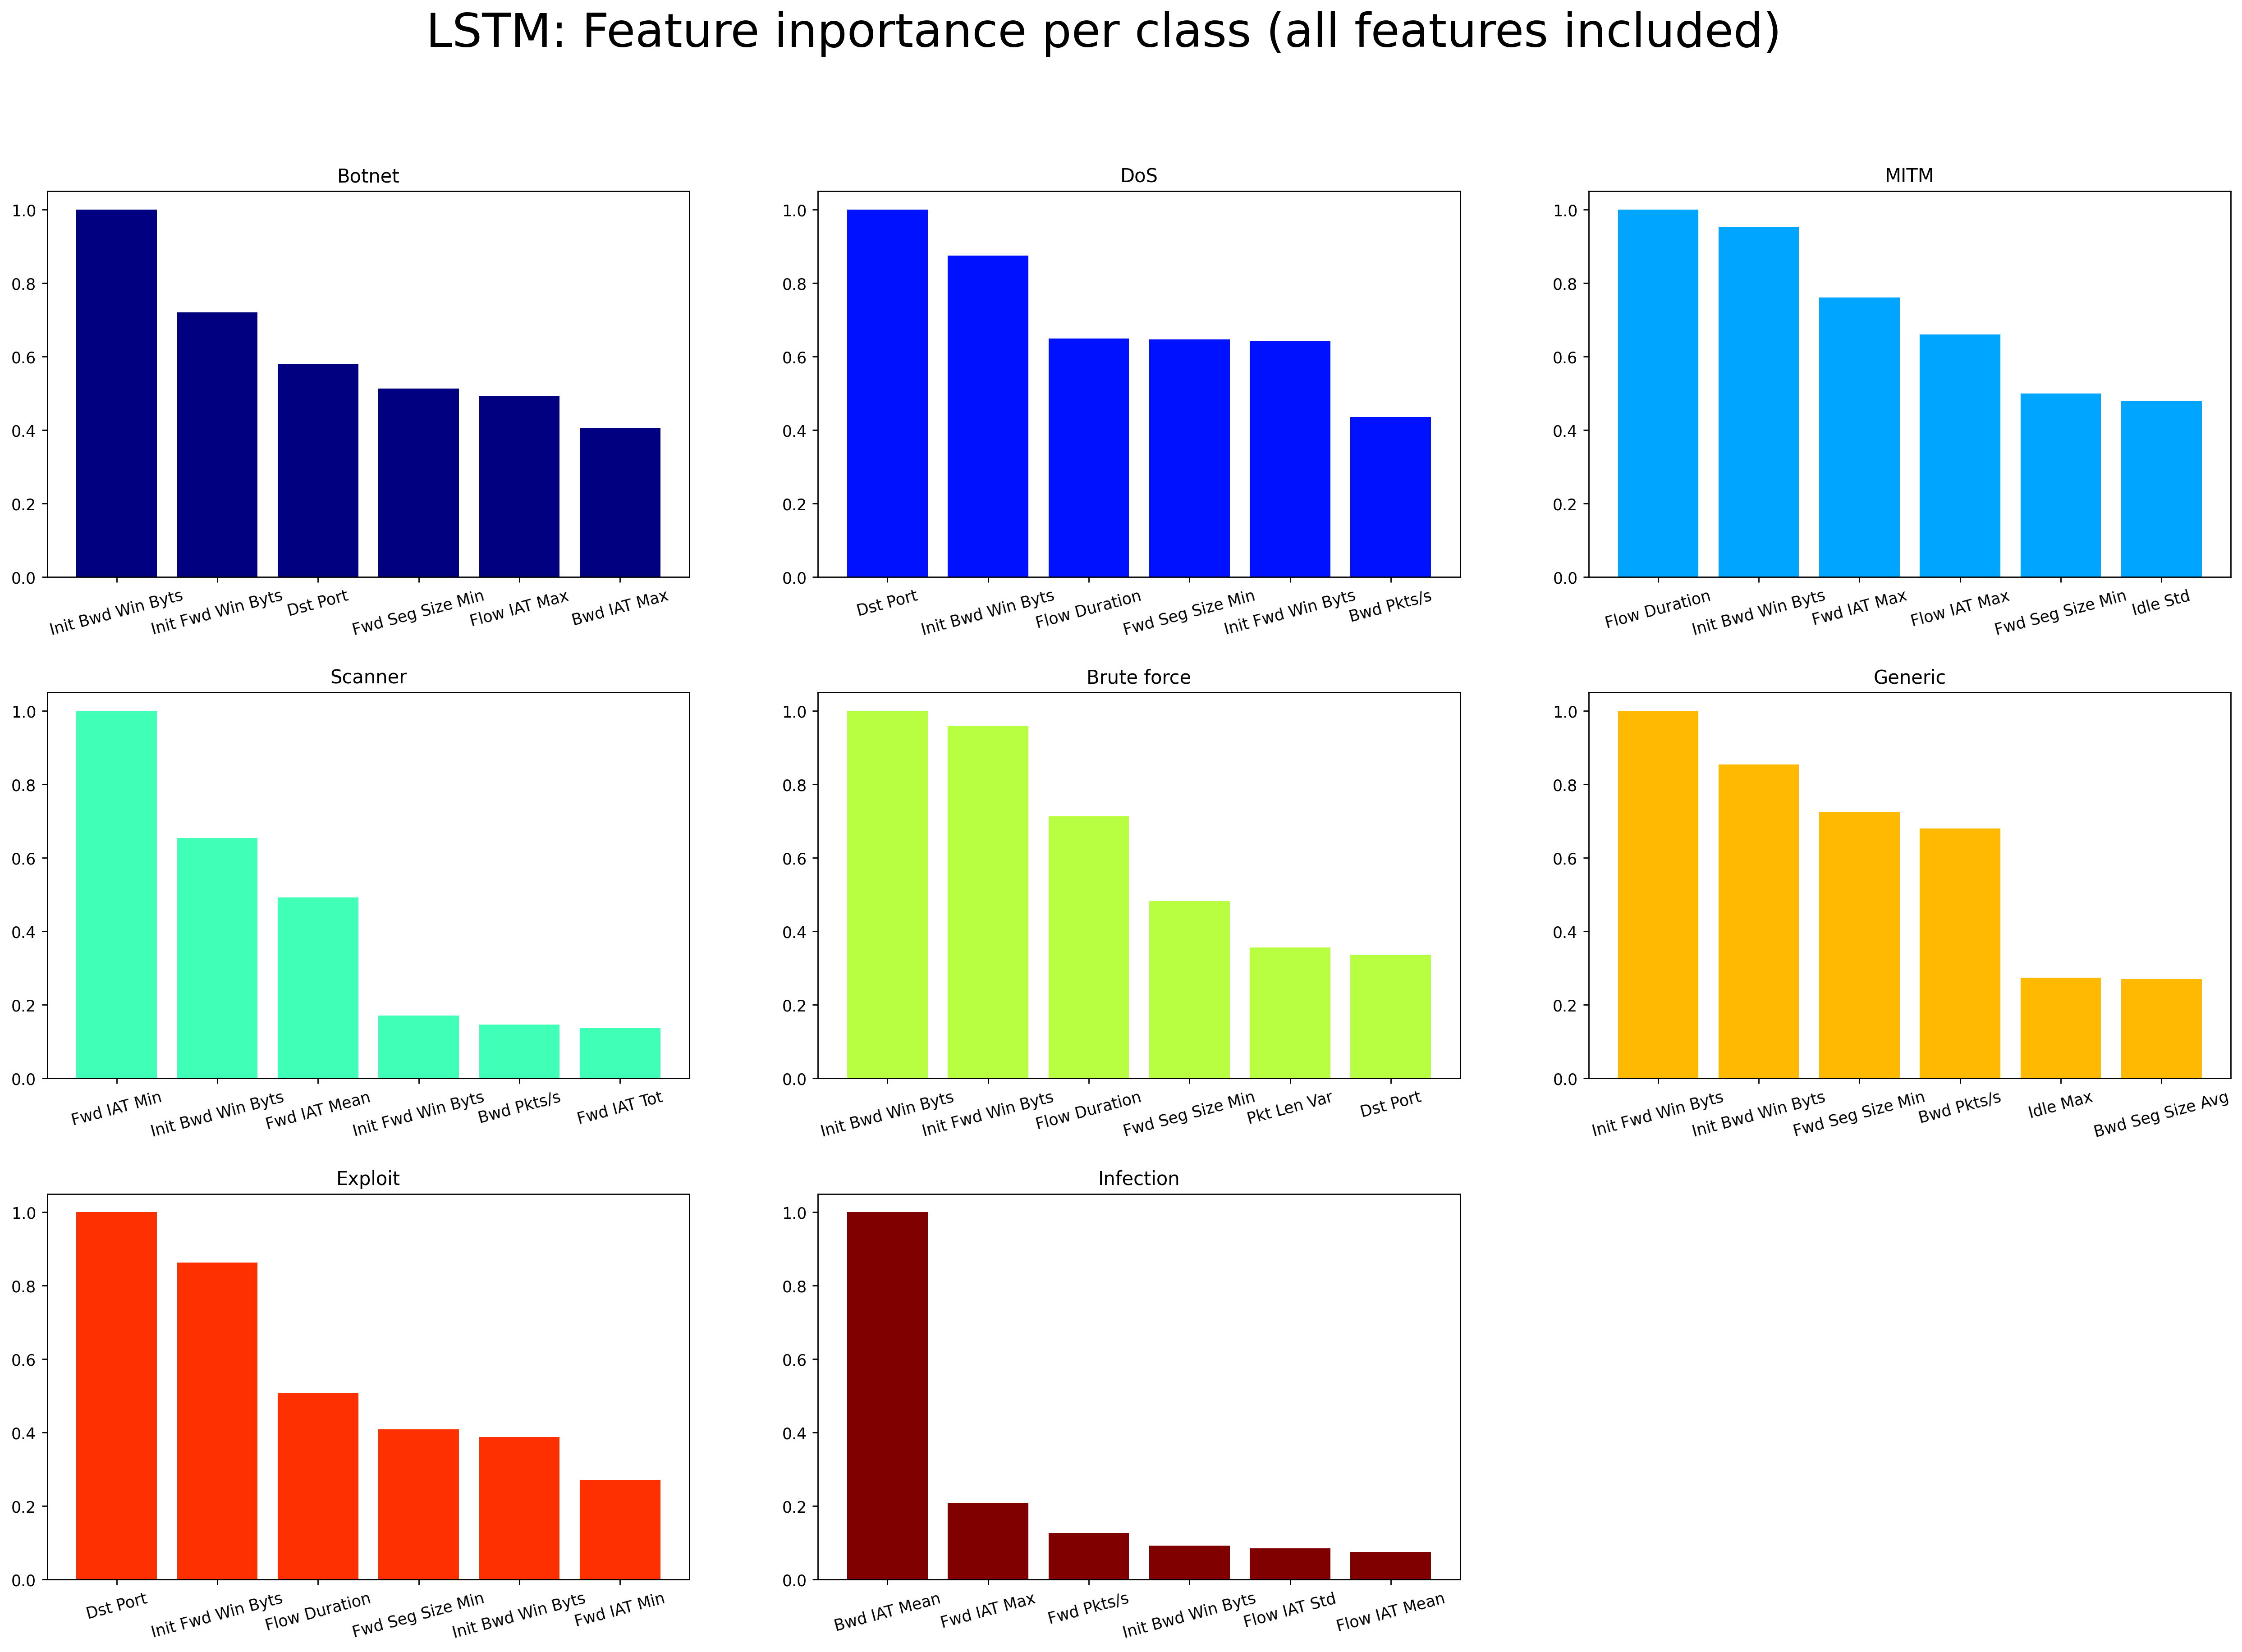

In [6]:
plot_shap_values(pd.read_csv(LSTM_SHAP_VALUES), "LSTM: Feature inportance per class (all features included)")

#### Separate removed features

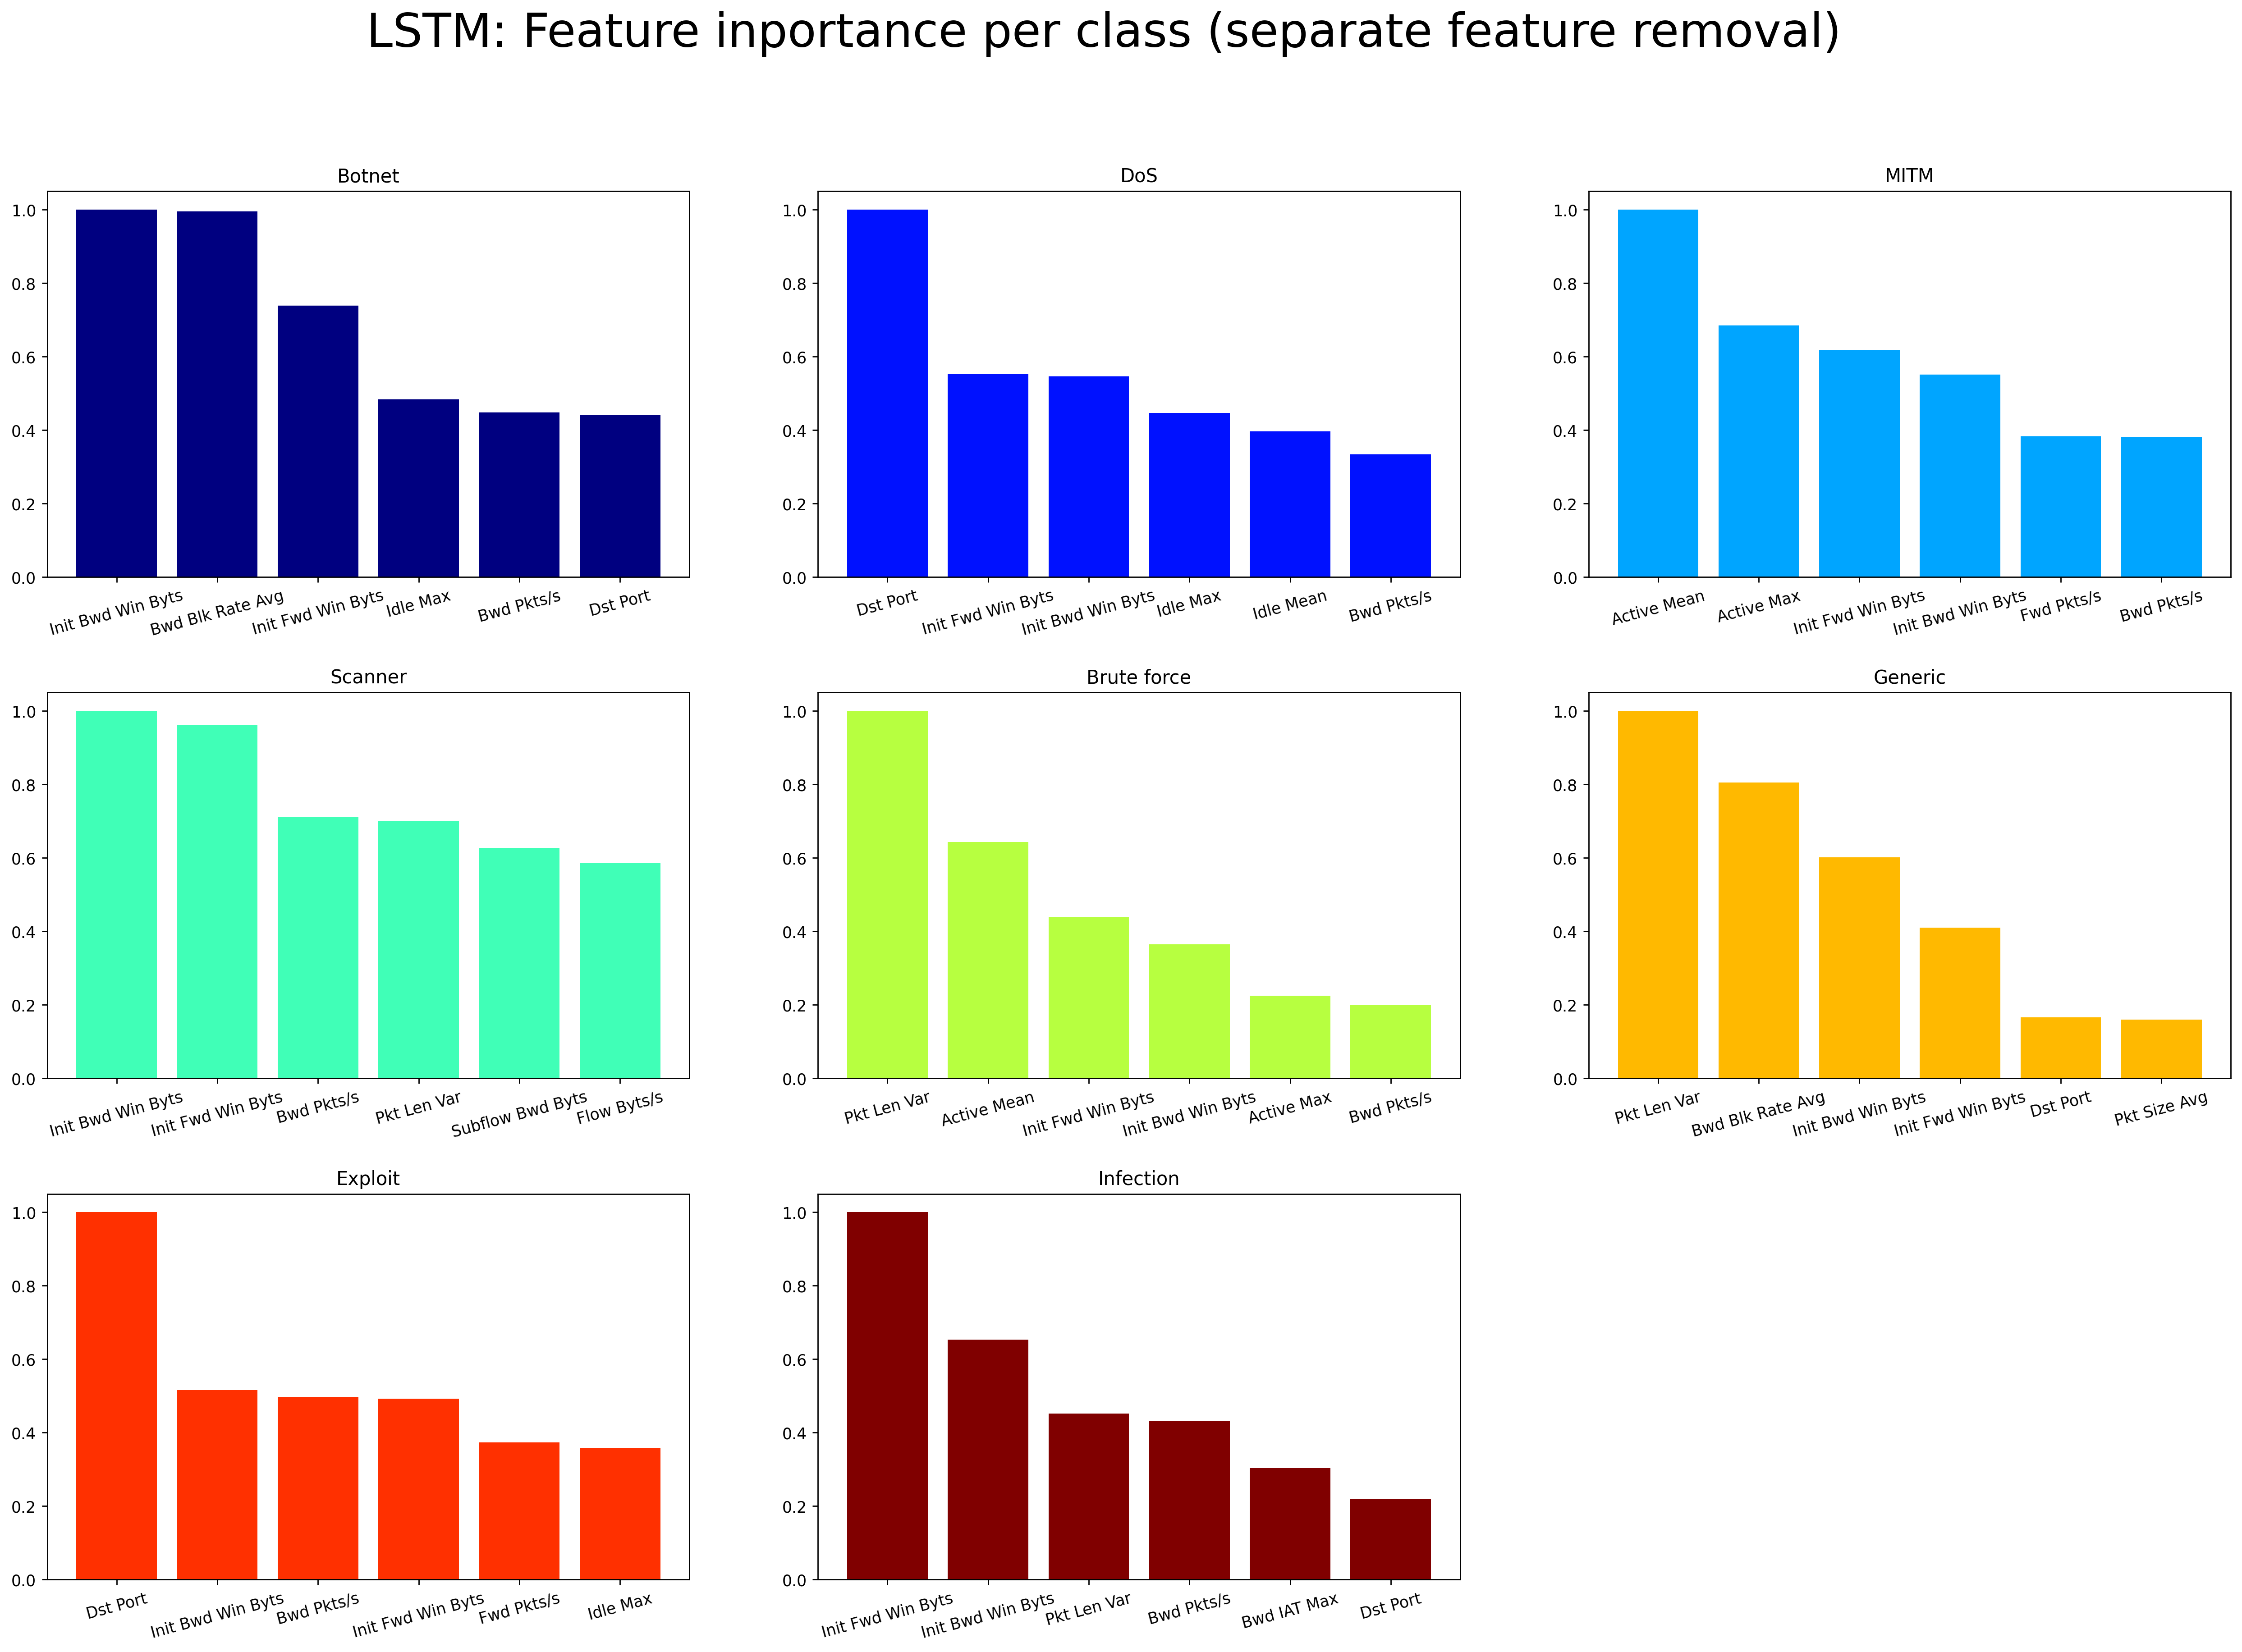

In [7]:
plot_shap_values(pd.read_csv(LSTM_SEP_REMOVED_SHAP_VALUES), "LSTM: Feature inportance per class (separate feature removal)")

### CNN
#### All network specific features included

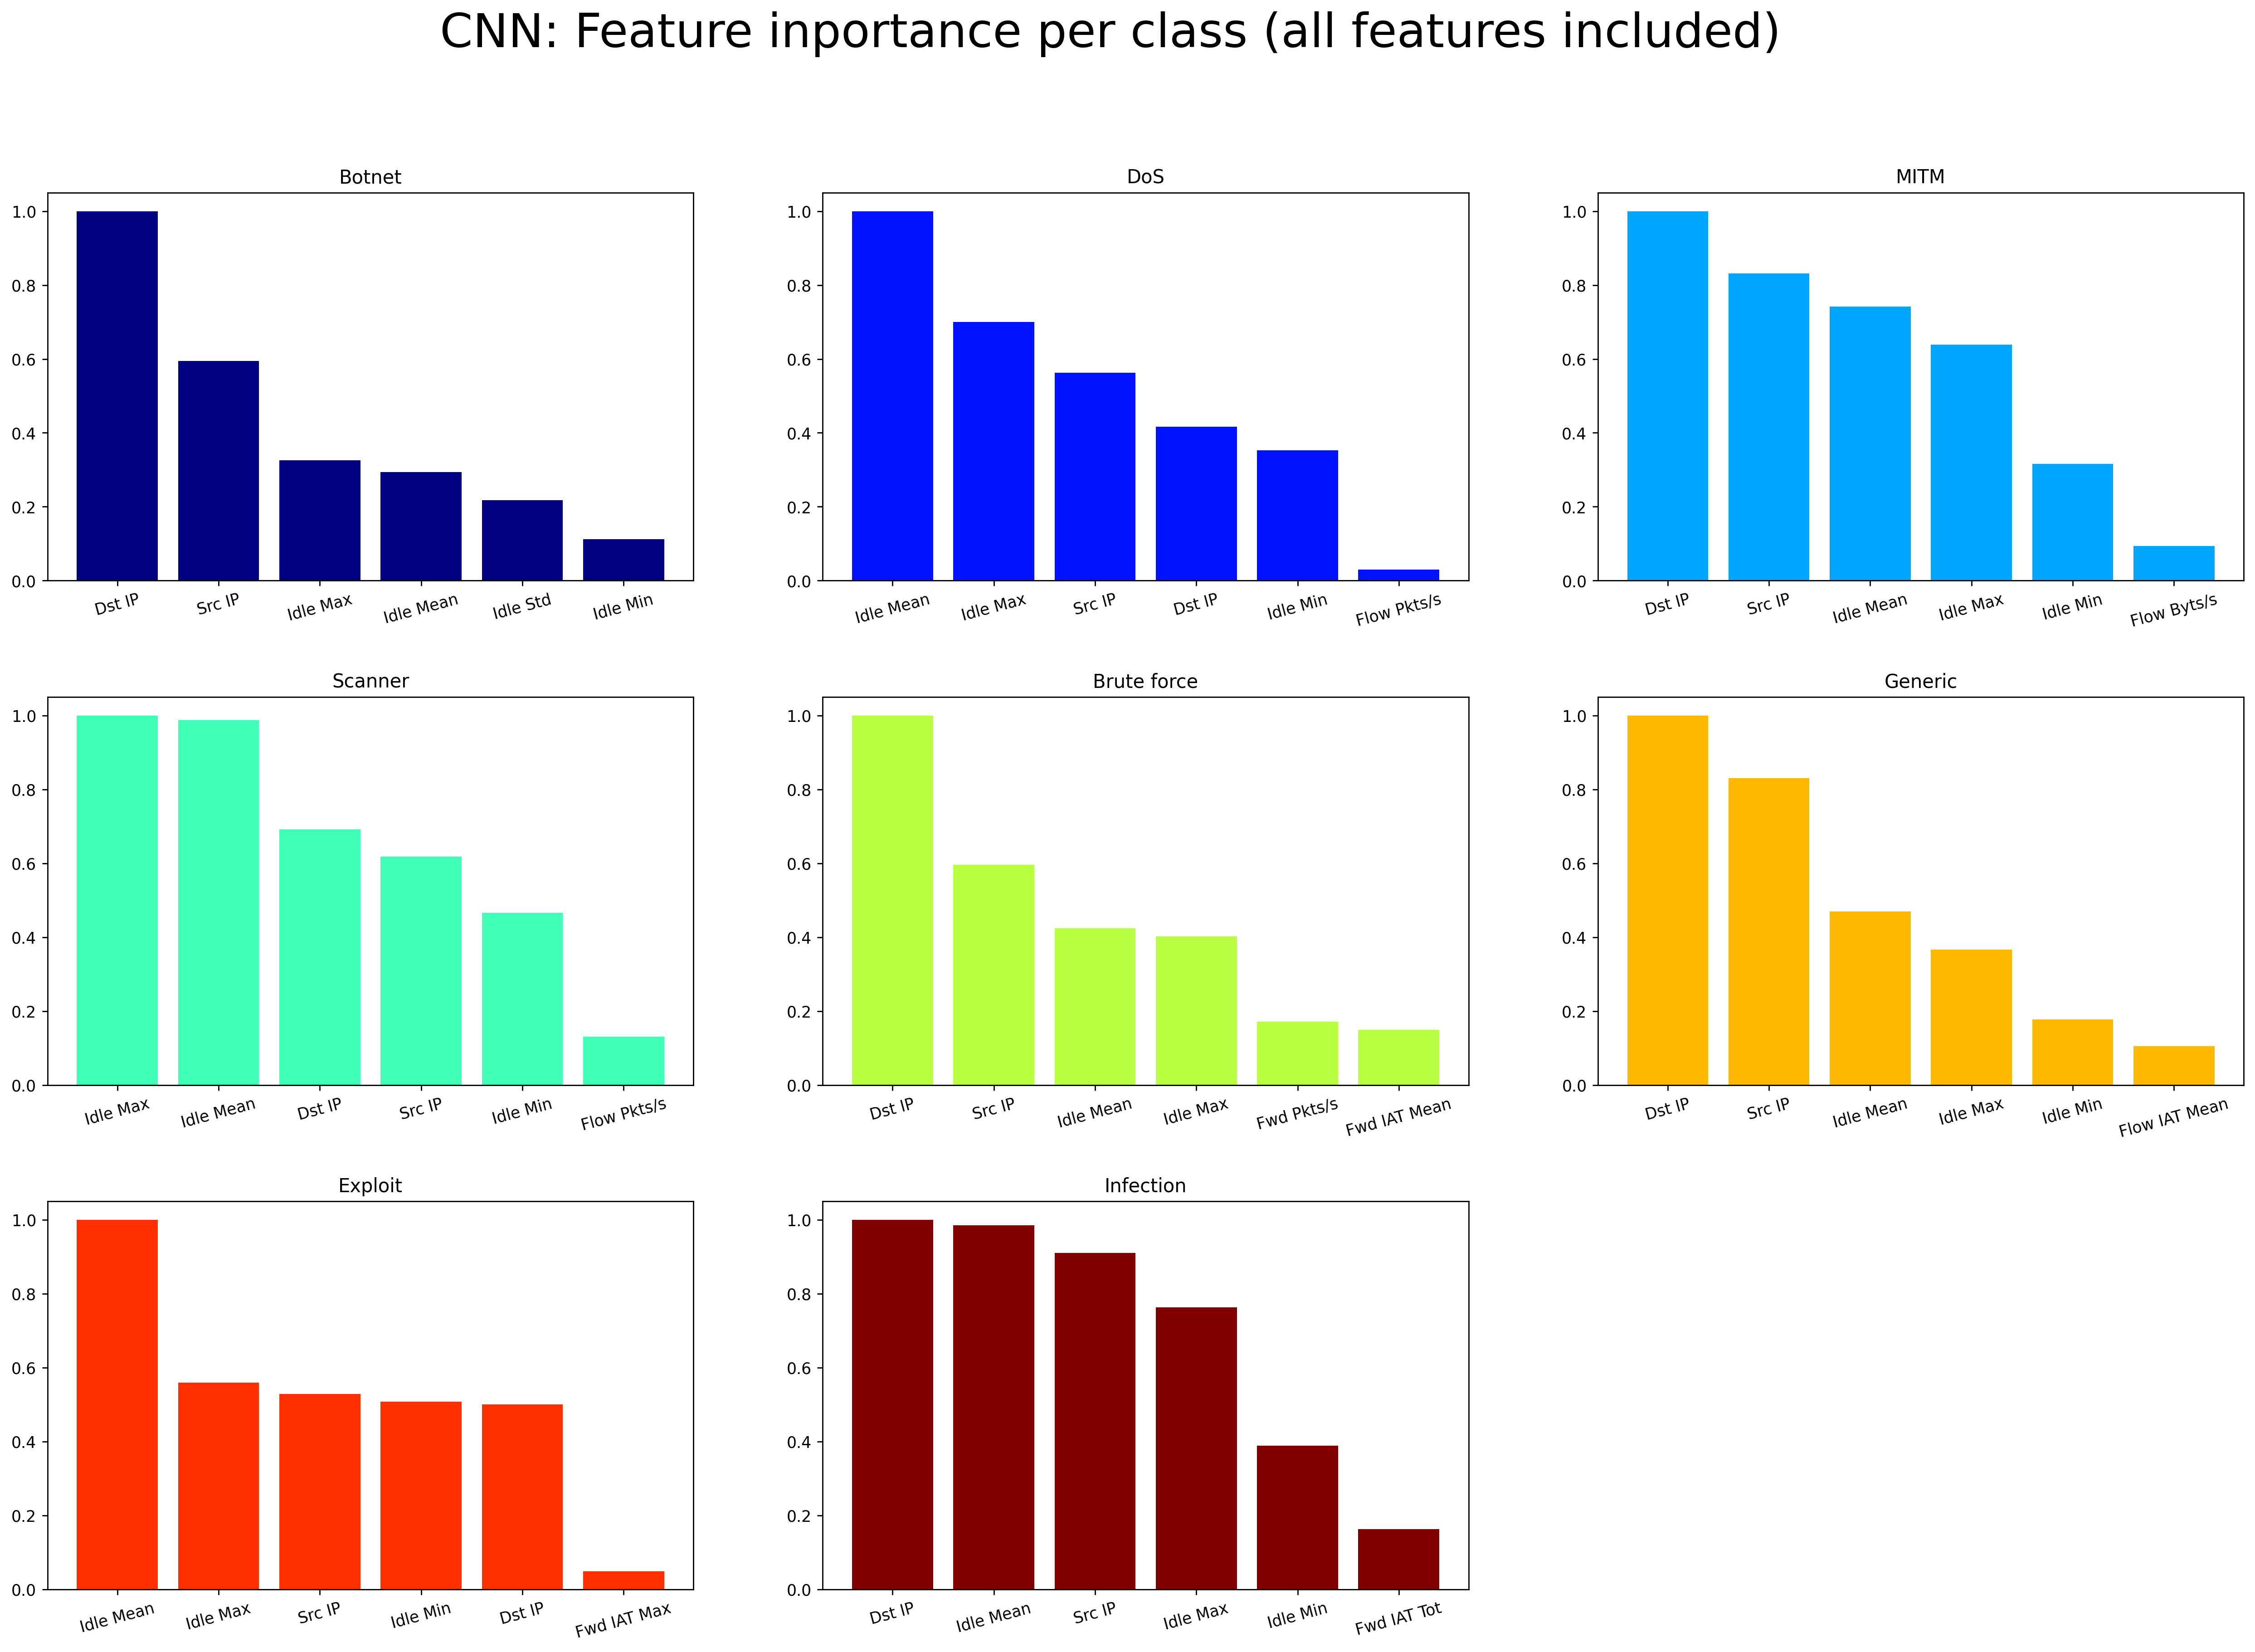

In [8]:
plot_shap_values(pd.read_csv(CNN_SHAP_VALUES), "CNN: Feature inportance per class (all features included)")

#### Separate removed features

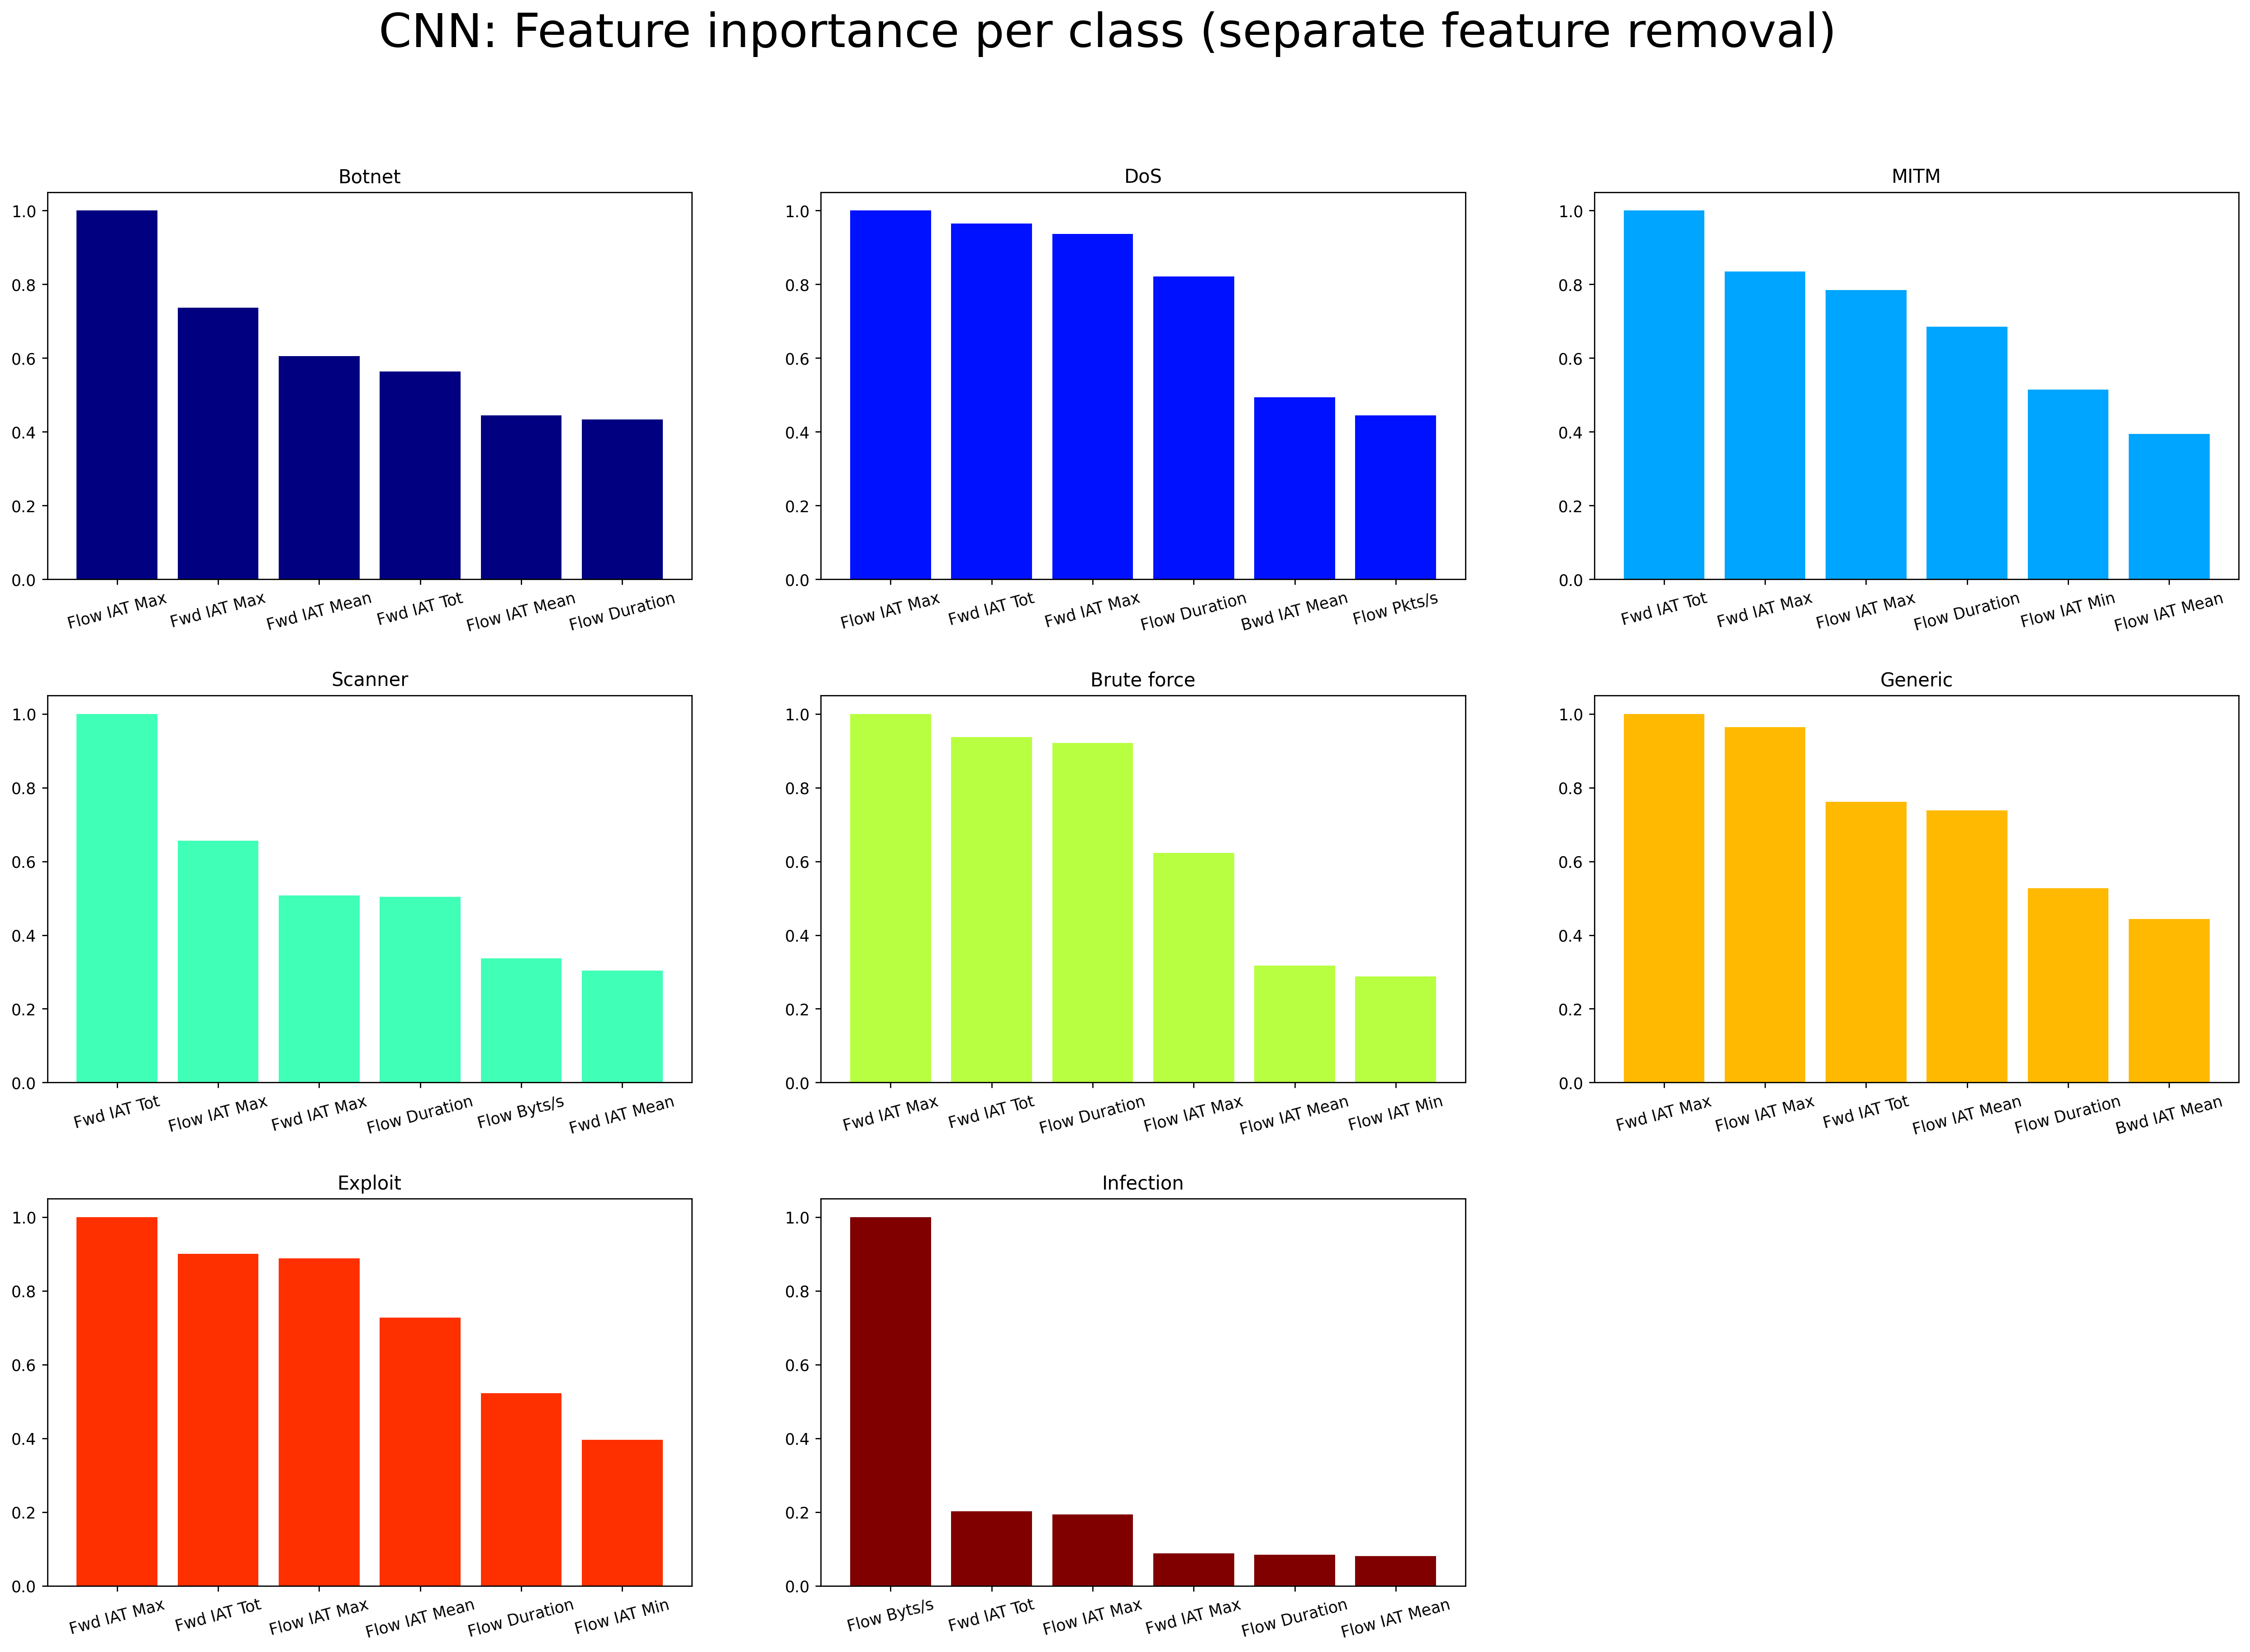

In [9]:
plot_shap_values(pd.read_csv(CNN_SEP_REMOVED_SHAP_VALUES), "CNN: Feature inportance per class (separate feature removal)")